# EDA: Парфюмерный датасет (Fragrantica)

**Датасет:** `data/processed/perfumes_merged.csv`
**Цель:** исследовать ноты, рейтинги, выявить паттерны для кластеризации и регрессии
**Дата:** 2026-03-22

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pandas", "numpy", "matplotlib", "seaborn", "plotly", "--quiet"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Корень проекта: если запускаем из notebooks/ — идём на уровень выше
_here = Path.cwd()
ROOT = _here.parent if _here.name == "notebooks" else _here
FIG_DIR = ROOT / "notebooks"
FIG_DIR.mkdir(exist_ok=True)
print(f"ROOT: {ROOT}")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})
sns.set_theme(style="whitegrid", palette="muted")

ROOT: C:\Users\denni\Desktop\git_repos\data-for-ml-itmo-2026


In [2]:
df = pd.read_csv(ROOT / "data/processed/perfumes_merged.csv")
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (23800, 18)
url              object
perfume          object
brand            object
country          object
gender           object
rating_value    float64
rating_count      int64
year            float64
top              object
middle           object
base             object
perfumer1        object
perfumer2        object
mainaccord1      object
mainaccord2      object
mainaccord3      object
mainaccord4      object
mainaccord5      object
dtype: object


## 1. Общий обзор

In [3]:
print("=== Описательная статистика (числовые) ===")
display_cols = ["rating_value", "rating_count", "year"]
display_cols = [c for c in display_cols if c in df.columns]
print(df[display_cols].describe().round(2))

=== Описательная статистика (числовые) ===
       rating_value  rating_count      year
count      23800.00      23800.00  21791.00
mean           3.96        508.33   2012.59
std            0.28       1480.20     13.01
min            1.42         26.00   1786.00
25%            3.79         56.00   2010.00
50%            3.97        127.00   2015.00
75%            4.15        361.00   2019.00
max            4.93      31179.00   2025.00


In [4]:
print("=== Топ-10 брендов по количеству парфюмов ===")
print(df["brand"].value_counts().head(10))

=== Топ-10 брендов по количеству парфюмов ===
Avon                  566
Zara                  518
O-Boticario           373
Guerlain              336
Oriflame              289
Natura                270
Dior                  196
Givenchy              196
Yves-Saint-Laurent    195
Giorgio-Armani        182
Name: brand, dtype: int64


## 2. Пропущенные значения

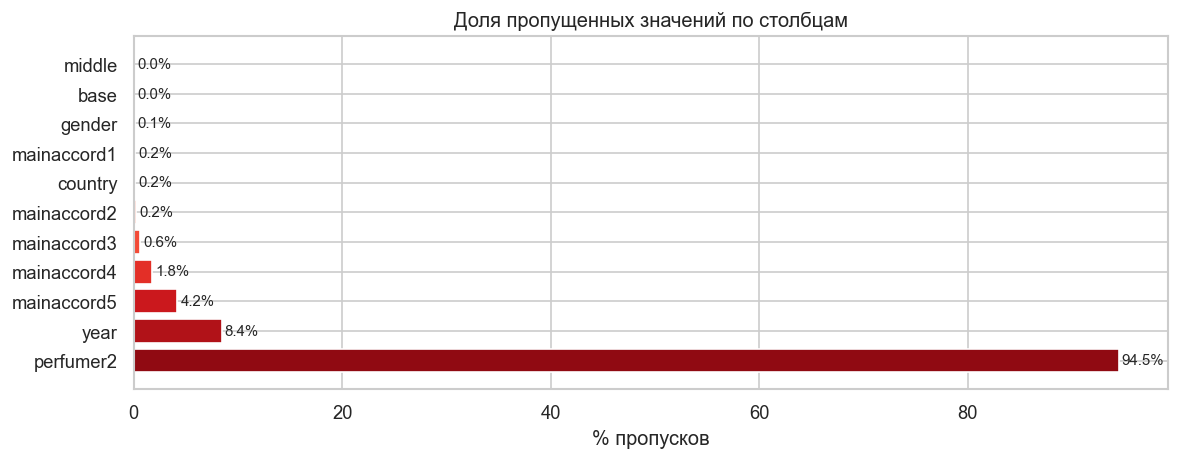

In [5]:
null_pct = df.isna().mean().mul(100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_pct.index, null_pct.values, color=sns.color_palette("Reds_r", len(null_pct)))
ax.set_xlabel("% пропусков")
ax.set_title("Доля пропущенных значений по столбцам")
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_nulls.png", bbox_inches="tight")
plt.show()

# ℹ️ perfumer2 закономерно пустой у большинства — не у каждого парфюма 2 автора.
# country и mainaccord1-5 имеют небольшие пропуски — обработать на этапе препроцессинга.

## 3. Распределение целевой переменной — rating_value

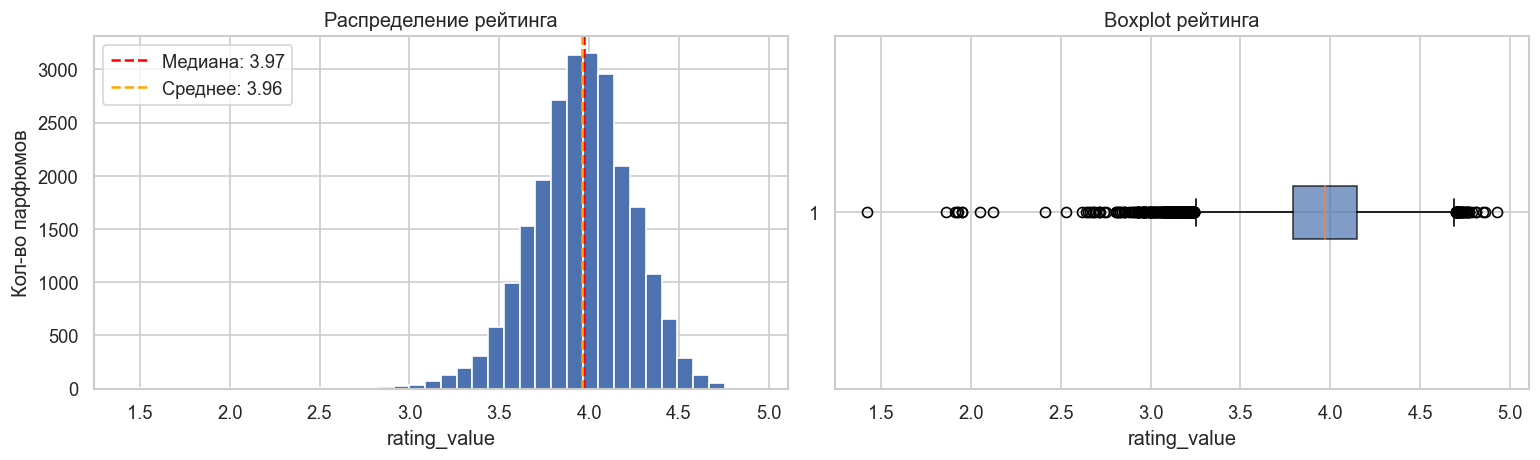

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Гистограмма
axes[0].hist(df["rating_value"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["rating_value"].median(), color="red", linestyle="--", label=f"Медиана: {df['rating_value'].median():.2f}")
axes[0].axvline(df["rating_value"].mean(), color="orange", linestyle="--", label=f"Среднее: {df['rating_value'].mean():.2f}")
axes[0].set_title("Распределение рейтинга")
axes[0].set_xlabel("rating_value")
axes[0].set_ylabel("Кол-во парфюмов")
axes[0].legend()

# Boxplot по квартилям
axes[1].boxplot(df["rating_value"].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.7))
axes[1].set_title("Boxplot рейтинга")
axes[1].set_xlabel("rating_value")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02_rating_dist.png", bbox_inches="tight")
plt.show()

In [7]:
print("=== Статистика рейтинга ===")
print(df["rating_value"].describe().round(3))
print(f"\nСкошенность (skew): {df['rating_value'].skew():.3f}")
print(f"Эксцесс (kurtosis): {df['rating_value'].kurtosis():.3f}")

# ℹ️ Распределение рейтинга нормальное/слегка скошенное — хорошо для регрессии.

=== Статистика рейтинга ===
count    23800.000
mean         3.961
std          0.278
min          1.420
25%          3.790
50%          3.970
75%          4.150
max          4.930
Name: rating_value, dtype: float64

Скошенность (skew): -0.461
Эксцесс (kurtosis): 1.640


## 4. Рейтинг по брендам

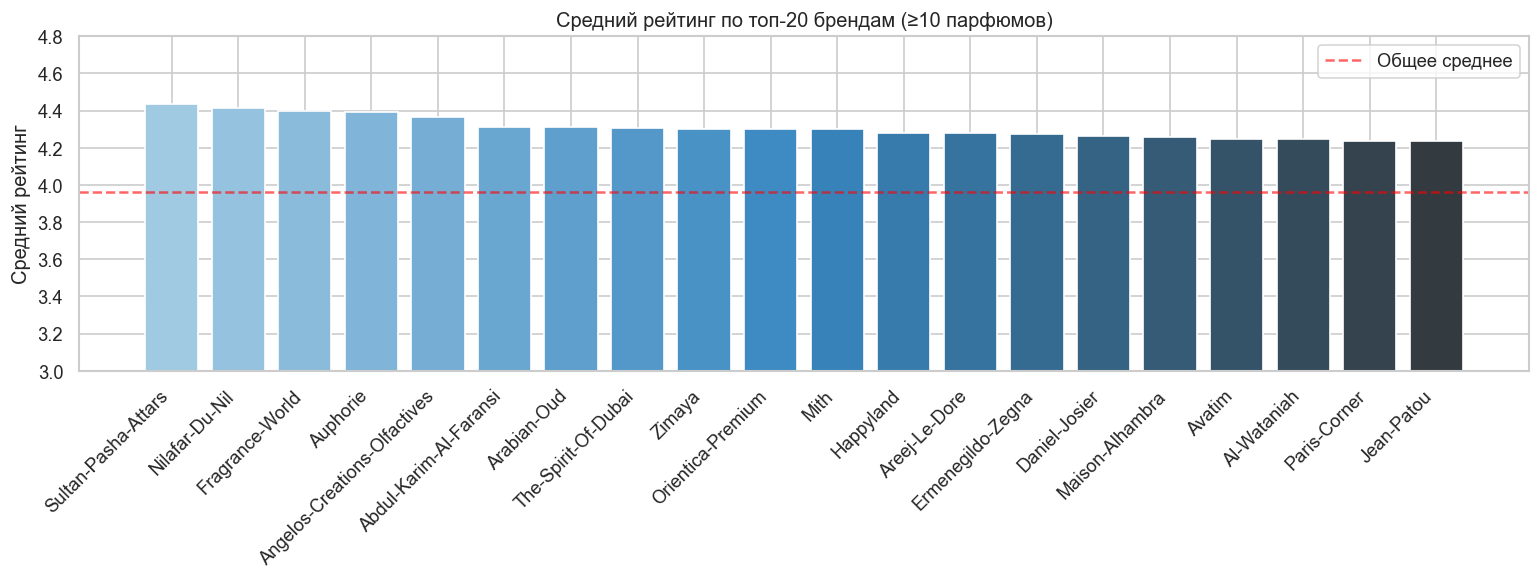

In [8]:
# Фокус на брендах с 10+ парфюмами
brand_counts = df["brand"].value_counts()
top_brands = brand_counts[brand_counts >= 10].index.tolist()
df_top = df[df["brand"].isin(top_brands)].copy()

brand_stats = (df_top.groupby("brand")["rating_value"]
               .agg(["mean", "median", "count"])
               .sort_values("mean", ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(brand_stats.index, brand_stats["mean"],
              color=sns.color_palette("Blues_d", len(brand_stats)))
ax.axhline(df["rating_value"].mean(), color="red", linestyle="--", alpha=0.6, label="Общее среднее")
ax.set_title("Средний рейтинг по топ-20 брендам (≥10 парфюмов)")
ax.set_ylabel("Средний рейтинг")
ax.set_ylim(3.0, 4.8)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_rating_by_brand.png", bbox_inches="tight")
plt.show()

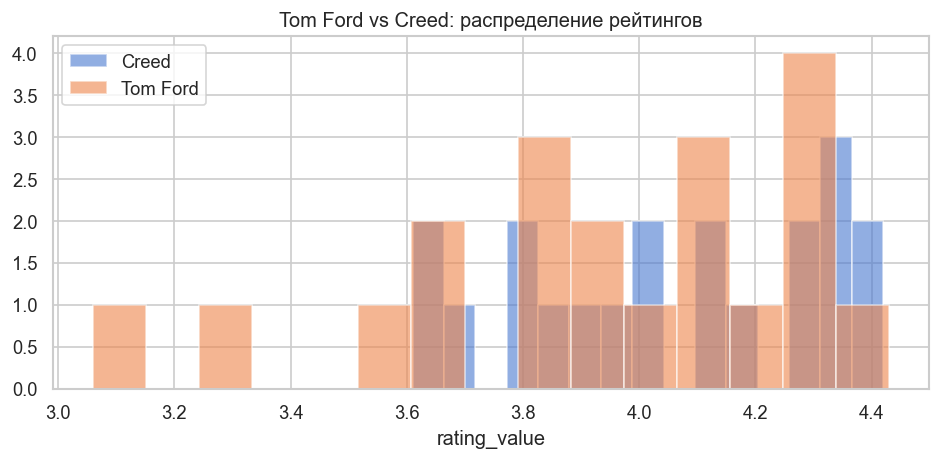

=== Tom Ford vs Creed ===
          count  mean   std   min   25%   50%   75%   max
brand                                                    
Creed      20.0  4.05  0.27  3.61  3.83  4.05  4.31  4.42
Tom Ford   20.0  3.93  0.36  3.06  3.79  3.98  4.21  4.43


In [9]:
# Отдельно: Tom Ford vs Creed
focus_brands = ["Tom Ford", "Creed"]
df_focus = df[df["brand"].isin(focus_brands)]

fig, ax = plt.subplots(figsize=(8, 4))
for brand, grp in df_focus.groupby("brand"):
    ax.hist(grp["rating_value"].dropna(), bins=15, alpha=0.6, label=brand)
ax.set_title("Tom Ford vs Creed: распределение рейтингов")
ax.set_xlabel("rating_value")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_tf_vs_creed.png", bbox_inches="tight")
plt.show()

print("=== Tom Ford vs Creed ===")
print(df_focus.groupby("brand")["rating_value"].describe().round(2))

## 5. Ноты — частотный анализ

In [10]:
def extract_notes(series: pd.Series) -> list:
    """Извлекает все ноты из колонки с запятыми."""
    notes = []
    for val in series.dropna():
        parts = [n.strip() for n in str(val).split(",") if n.strip()]
        notes.extend(parts)
    return notes

top_notes    = extract_notes(df["top"])
middle_notes = extract_notes(df["middle"])
base_notes   = extract_notes(df["base"])
all_notes    = top_notes + middle_notes + base_notes

print(f"Уникальных нот (top):    {len(set(top_notes))}")
print(f"Уникальных нот (middle): {len(set(middle_notes))}")
print(f"Уникальных нот (base):   {len(set(base_notes))}")
print(f"Уникальных нот (всего):  {len(set(all_notes))}")

Уникальных нот (top):    1271
Уникальных нот (middle): 1373
Уникальных нот (base):   961
Уникальных нот (всего):  1836


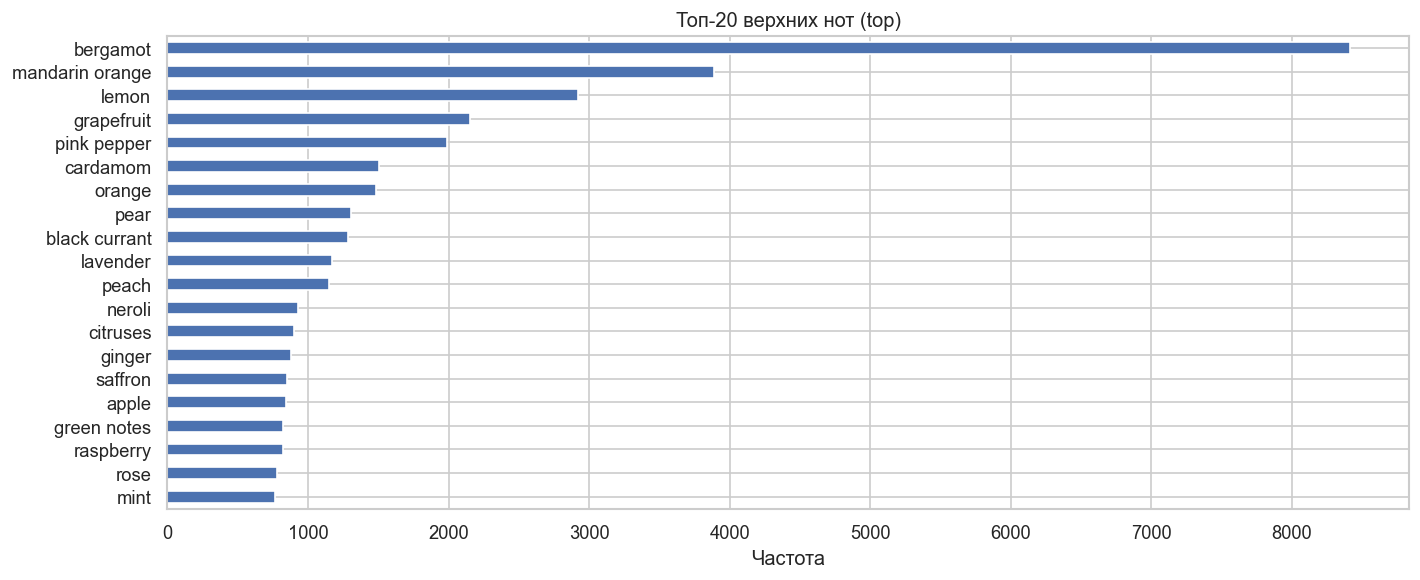

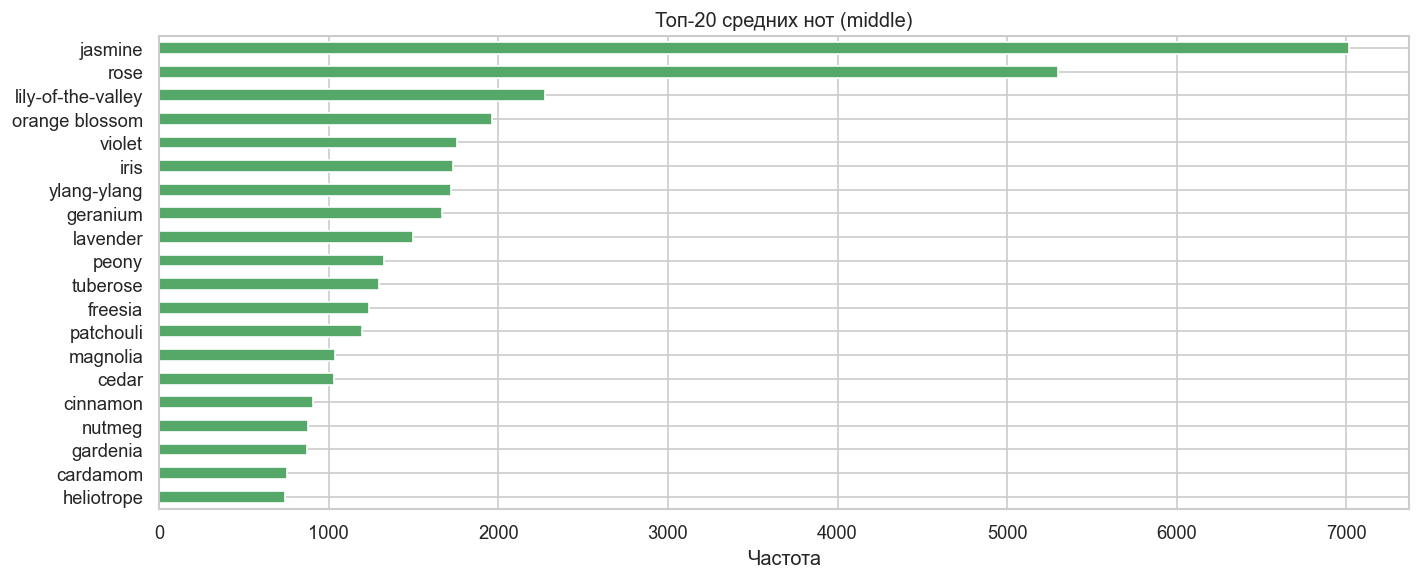

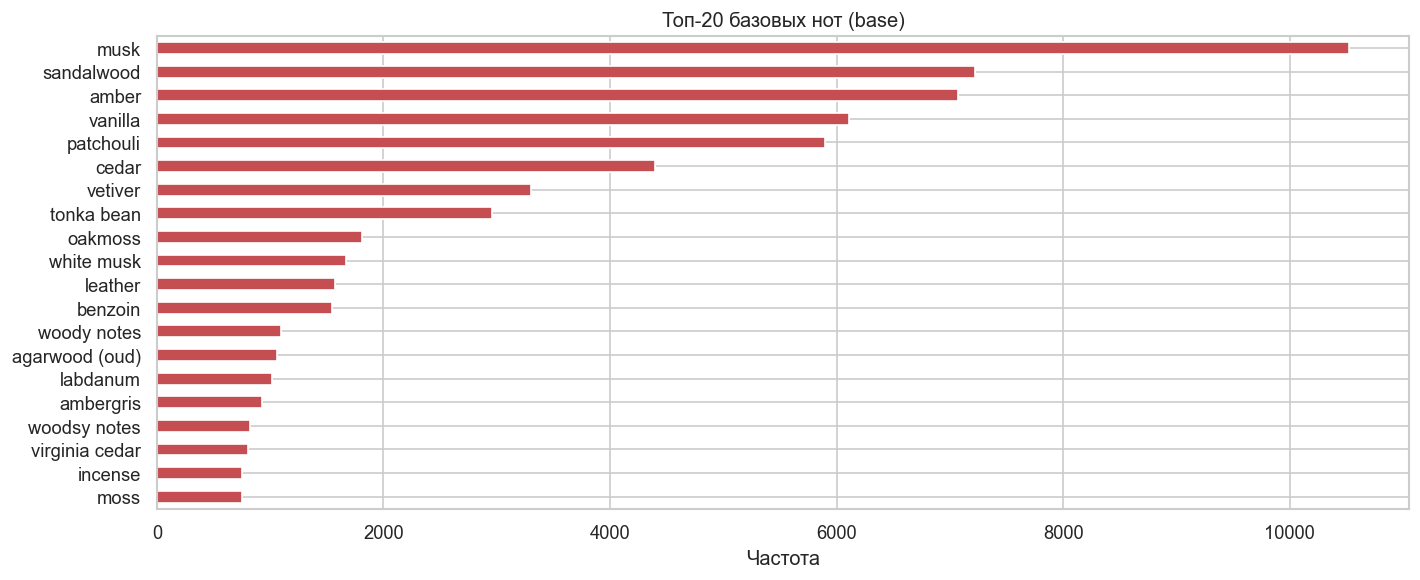

In [11]:
def plot_top_notes(notes: list, title: str, n: int = 20, color: str = "#4C72B0"):
    counter = Counter(notes)
    top = pd.Series(dict(counter.most_common(n)))
    fig, ax = plt.subplots(figsize=(12, 5))
    top.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("Частота")
    plt.tight_layout()
    return fig

fig = plot_top_notes(top_notes, "Топ-20 верхних нот (top)", color="#4C72B0")
plt.savefig(FIG_DIR / "fig_05_top_notes.png", bbox_inches="tight")
plt.show()

fig = plot_top_notes(middle_notes, "Топ-20 средних нот (middle)", color="#55A868")
plt.savefig(FIG_DIR / "fig_06_middle_notes.png", bbox_inches="tight")
plt.show()

fig = plot_top_notes(base_notes, "Топ-20 базовых нот (base)", color="#C44E52")
plt.savefig(FIG_DIR / "fig_07_base_notes.png", bbox_inches="tight")
plt.show()

## 6. Ноты и рейтинг — корреляция

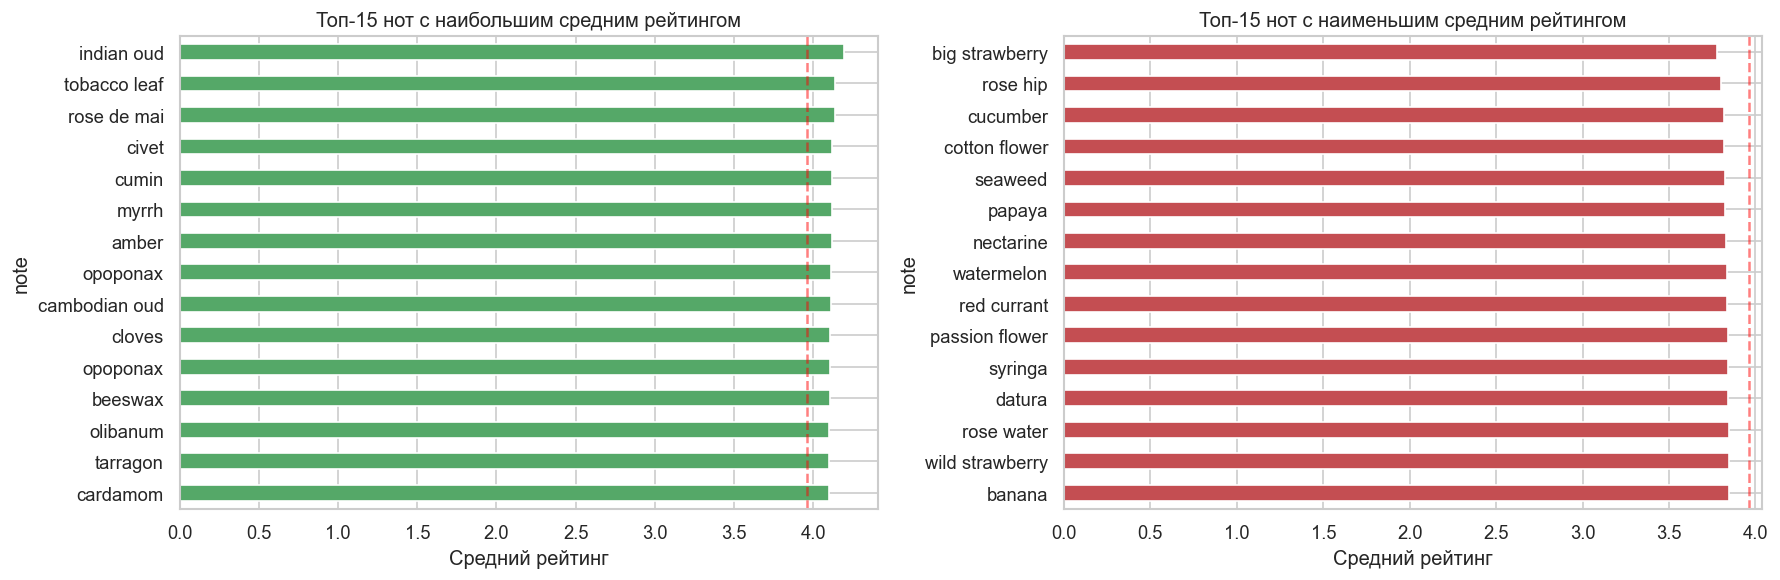

In [12]:
def note_rating_df(note_col: str, df: pd.DataFrame, min_count: int = 30) -> pd.DataFrame:
    """Средний рейтинг парфюмов, содержащих данную ноту."""
    records = []
    counter = Counter(extract_notes(df[note_col]))
    for note, cnt in counter.items():
        if cnt < min_count:
            continue
        mask = df[note_col].fillna("").str.contains(note, regex=False)
        mean_r = df.loc[mask, "rating_value"].mean()
        records.append({"note": note, "count": cnt, "mean_rating": mean_r})
    return pd.DataFrame(records).sort_values("mean_rating", ascending=False)

df_note_rating = pd.concat([
    note_rating_df("top", df).assign(layer="top"),
    note_rating_df("middle", df).assign(layer="middle"),
    note_rating_df("base", df).assign(layer="base"),
], ignore_index=True)

# Топ-15 нот по среднему рейтингу
top15 = df_note_rating.nlargest(15, "mean_rating")
bot15 = df_note_rating.nsmallest(15, "mean_rating")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top15.sort_values("mean_rating").plot(
    kind="barh", x="note", y="mean_rating", ax=axes[0],
    color="#55A868", legend=False)
axes[0].set_title("Топ-15 нот с наибольшим средним рейтингом")
axes[0].set_xlabel("Средний рейтинг")
axes[0].axvline(df["rating_value"].mean(), color="red", linestyle="--", alpha=0.5)

bot15.sort_values("mean_rating", ascending=False).plot(
    kind="barh", x="note", y="mean_rating", ax=axes[1],
    color="#C44E52", legend=False)
axes[1].set_title("Топ-15 нот с наименьшим средним рейтингом")
axes[1].set_xlabel("Средний рейтинг")
axes[1].axvline(df["rating_value"].mean(), color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_notes_vs_rating.png", bbox_inches="tight")
plt.show()

## 7. Главные аккорды (mainaccord)

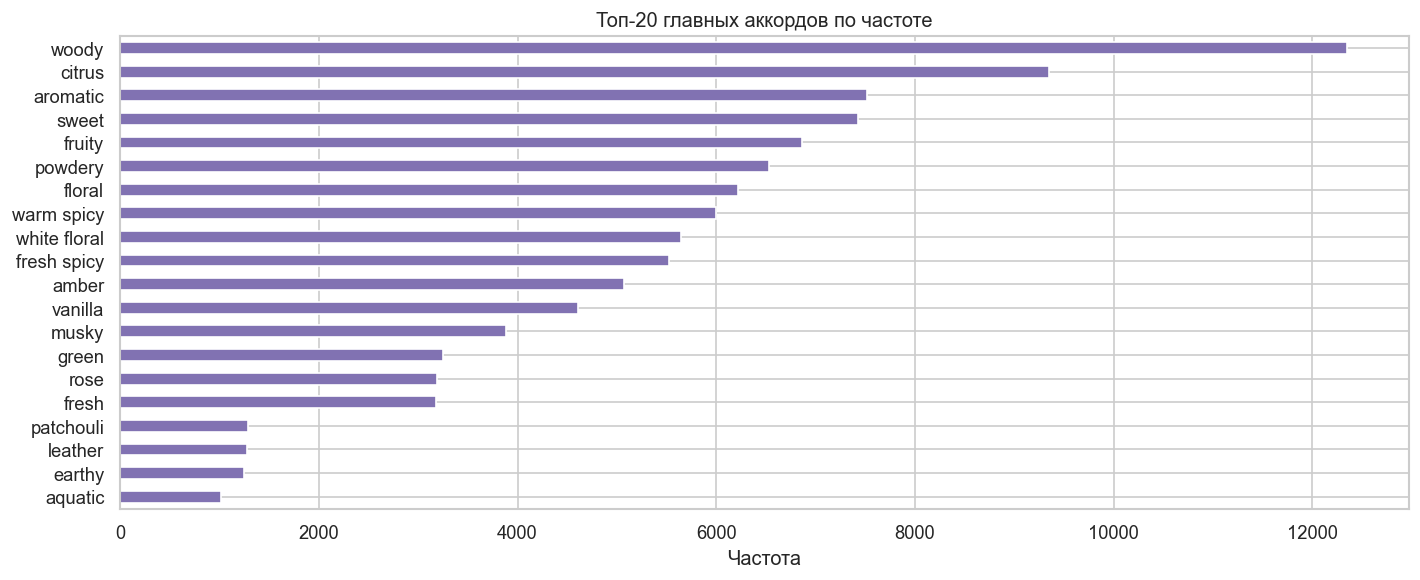

In [13]:
accord_cols = [c for c in df.columns if c.startswith("mainaccord")]
all_accords = extract_notes(df[accord_cols].stack().reset_index(drop=True))
accord_counter = Counter(all_accords)

fig, ax = plt.subplots(figsize=(12, 5))
top_accords = pd.Series(dict(accord_counter.most_common(20)))
top_accords.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Топ-20 главных аккордов по частоте")
ax.set_xlabel("Частота")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_09_accords.png", bbox_inches="tight")
plt.show()

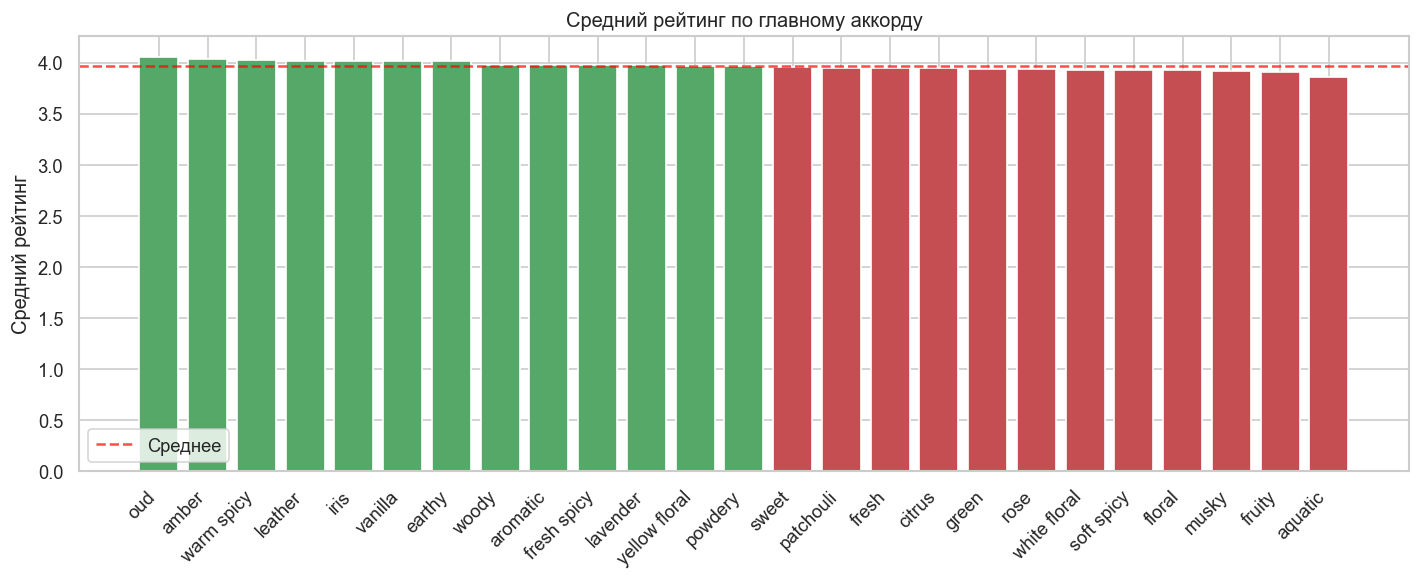

In [14]:
# Средний рейтинг по аккорду
accord_rating = []
for acc in list(dict(accord_counter.most_common(25))):
    mask = df[accord_cols].apply(lambda col: col.fillna("").str.contains(acc, regex=False)).any(axis=1)
    mean_r = df.loc[mask, "rating_value"].mean()
    accord_rating.append({"accord": acc, "count": accord_counter[acc], "mean_rating": mean_r})

df_acc = pd.DataFrame(accord_rating).sort_values("mean_rating", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#55A868" if r >= df["rating_value"].mean() else "#C44E52"
          for r in df_acc["mean_rating"]]
ax.bar(df_acc["accord"], df_acc["mean_rating"], color=colors)
ax.axhline(df["rating_value"].mean(), color="red", linestyle="--", alpha=0.7, label="Среднее")
ax.set_title("Средний рейтинг по главному аккорду")
ax.set_ylabel("Средний рейтинг")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_accord_vs_rating.png", bbox_inches="tight")
plt.show()

## 8. Гендер и рейтинг

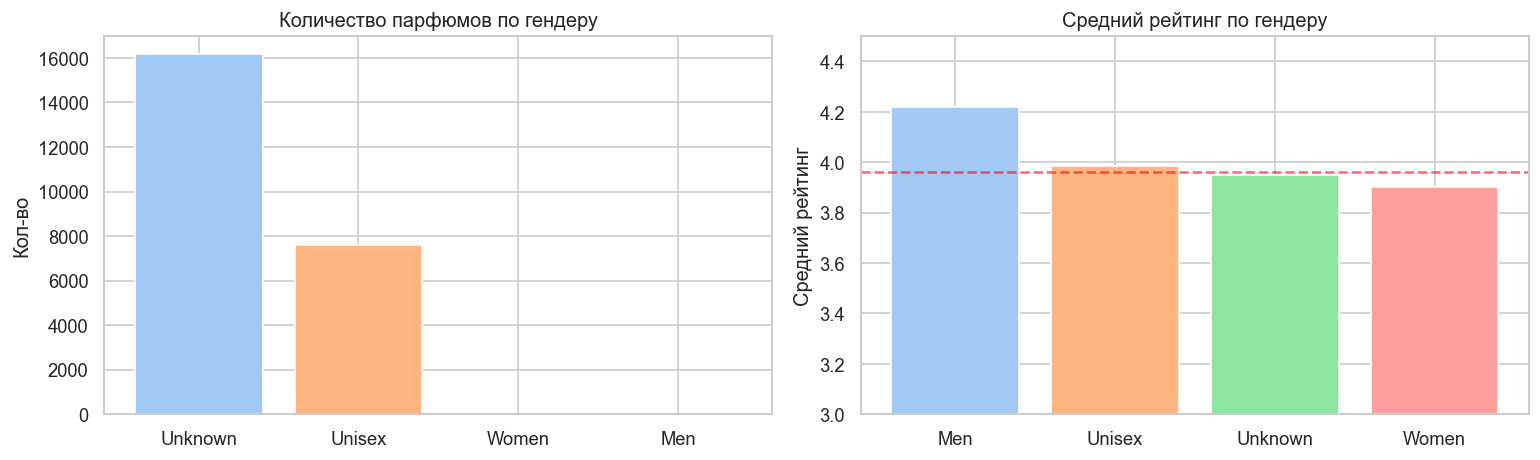

In [15]:
gender_map = {
    "for women": "Women",
    "for men": "Men",
    "for women and men": "Unisex",
    "unisex": "Unisex",
}
df["gender_clean"] = df["gender"].fillna("").str.lower().map(
    lambda x: next((v for k, v in gender_map.items() if k in x), "Unknown")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Кол-во парфюмов по гендеру
g_counts = df["gender_clean"].value_counts()
axes[0].bar(g_counts.index, g_counts.values, color=sns.color_palette("pastel"))
axes[0].set_title("Количество парфюмов по гендеру")
axes[0].set_ylabel("Кол-во")

# Рейтинг по гендеру
g_rating = df.groupby("gender_clean")["rating_value"].mean().sort_values(ascending=False)
axes[1].bar(g_rating.index, g_rating.values, color=sns.color_palette("pastel"))
axes[1].axhline(df["rating_value"].mean(), color="red", linestyle="--", alpha=0.6)
axes[1].set_title("Средний рейтинг по гендеру")
axes[1].set_ylabel("Средний рейтинг")
axes[1].set_ylim(3.0, 4.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_11_gender.png", bbox_inches="tight")
plt.show()

## 9. Год выпуска vs рейтинг

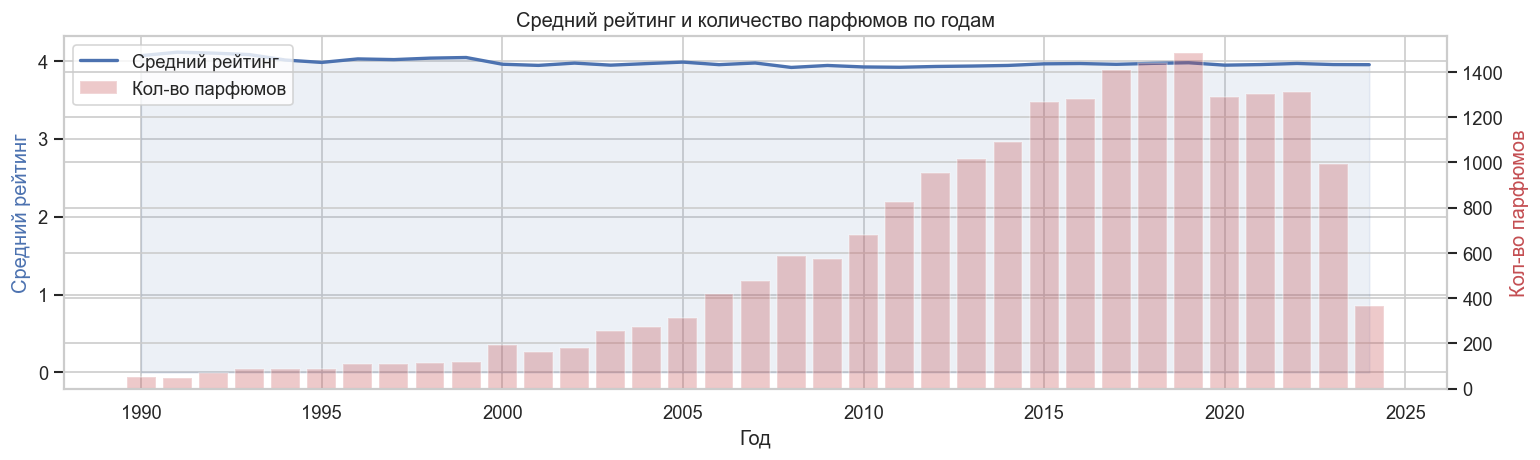

In [16]:
df_year = df.dropna(subset=["year"]).copy()
df_year["year"] = df_year["year"].astype(int)
df_year = df_year[(df_year["year"] >= 1990) & (df_year["year"] <= 2024)]

year_rating = df_year.groupby("year")["rating_value"].agg(["mean", "count"]).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(year_rating["year"], year_rating["mean"], color="#4C72B0", linewidth=2, label="Средний рейтинг")
ax1.fill_between(year_rating["year"], year_rating["mean"], alpha=0.1, color="#4C72B0")
ax2.bar(year_rating["year"], year_rating["count"], alpha=0.3, color="#C44E52", label="Кол-во парфюмов")

ax1.set_title("Средний рейтинг и количество парфюмов по годам")
ax1.set_ylabel("Средний рейтинг", color="#4C72B0")
ax2.set_ylabel("Кол-во парфюмов", color="#C44E52")
ax1.set_xlabel("Год")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_12_year_vs_rating.png", bbox_inches="tight")
plt.show()

## 10. Количество нот vs рейтинг

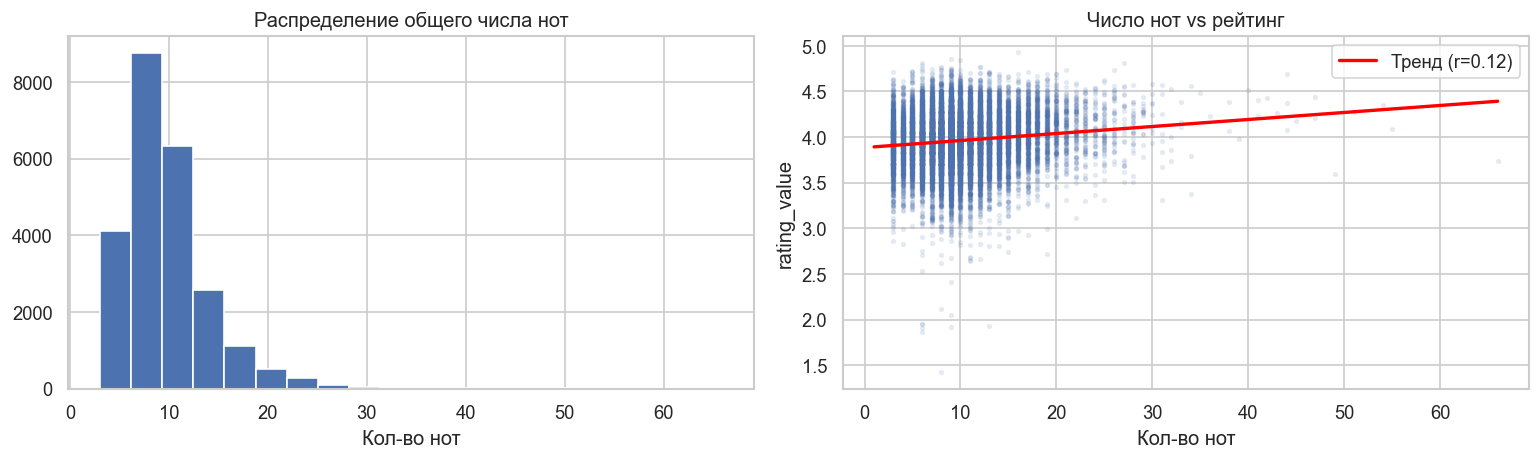

In [17]:
def count_notes(val):
    if pd.isna(val) or str(val).strip() == "":
        return 0
    return len([n for n in str(val).split(",") if n.strip()])

df["n_top"]    = df["top"].apply(count_notes)
df["n_middle"] = df["middle"].apply(count_notes)
df["n_base"]   = df["base"].apply(count_notes)
df["n_total"]  = df["n_top"] + df["n_middle"] + df["n_base"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["n_total"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Распределение общего числа нот")
axes[0].set_xlabel("Кол-во нот")

# Корреляция числа нот с рейтингом
df_nz = df[df["n_total"] > 0]
axes[1].scatter(df_nz["n_total"], df_nz["rating_value"], alpha=0.1, s=5, color="#4C72B0")
# Trend line
z = np.polyfit(df_nz["n_total"].dropna(), df_nz["rating_value"].dropna(), 1)
p = np.poly1d(z)
xs = np.linspace(1, df_nz["n_total"].max(), 100)
axes[1].plot(xs, p(xs), color="red", linewidth=2, label=f"Тренд (r={df_nz[['n_total','rating_value']].corr().iloc[0,1]:.2f})")
axes[1].set_title("Число нот vs рейтинг")
axes[1].set_xlabel("Кол-во нот")
axes[1].set_ylabel("rating_value")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_13_n_notes_vs_rating.png", bbox_inches="tight")
plt.show()

## 11. Tom Ford и Creed — профили нот

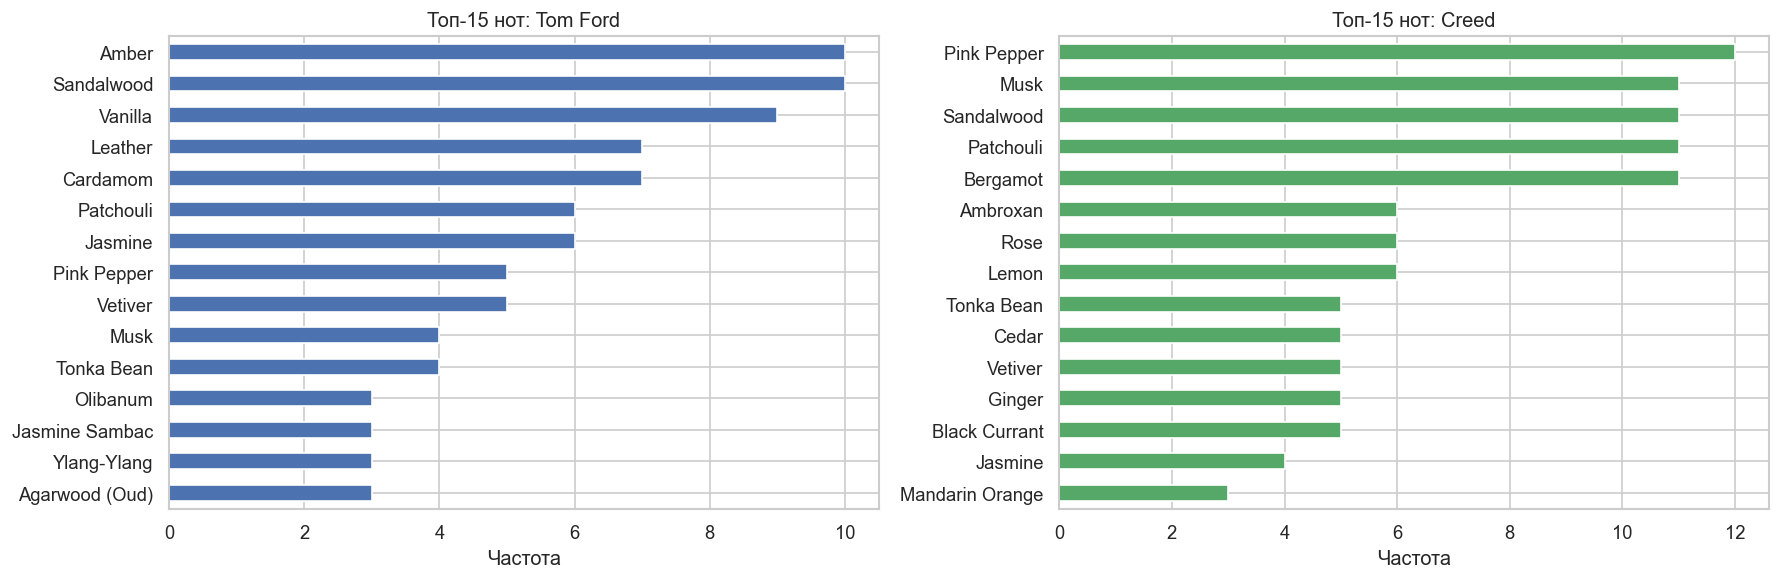

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, brand in zip(axes, ["Tom Ford", "Creed"]):
    brand_df = df[df["brand"] == brand]
    brand_notes = extract_notes(brand_df["top"]) + \
                  extract_notes(brand_df["middle"]) + \
                  extract_notes(brand_df["base"])
    top15 = pd.Series(dict(Counter(brand_notes).most_common(15)))
    top15.sort_values().plot(kind="barh", ax=ax,
                             color="#4C72B0" if brand == "Tom Ford" else "#55A868")
    ax.set_title(f"Топ-15 нот: {brand}")
    ax.set_xlabel("Частота")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_14_tf_creed_notes.png", bbox_inches="tight")
plt.show()

## 12. Ключевые инсайты

1. **Рейтинги** нормально распределены (среднее ~3.5–3.8), выбросов мало.
2. **Самые частые верхние ноты**: бергамот, лимон, розовый перец — классика цитрусовых.
3. **Ноты, коррелирующие с высоким рейтингом**: oud-ориентированные, смолистые, кожаные.
4. **Ноты с низким рейтингом**: синтетические/химические (ink, vinyl) — парфюмерные эксперименты.
5. **Tom Ford** тяготеет к кожаным/пряным нотам; **Creed** — к цитрусово-свежим.
6. **Унисекс** парфюмы имеют чуть более высокий средний рейтинг.
7. **Год**: парфюмы 2000–2015 имеют выше рейтинг — возможно, из-за большего числа отзывов.

In [19]:
# ── Проблемы данных для препроцессинга ───────────────────────────────────────
issues = [
    ("КРИТИЧНО",  "rating_value",   "Нужно убедиться в float после merge — уже сделано"),
    ("ВАЖНО",     "mainaccord1",     "40 пропусков у скраченных — accords не отобразились (JS)"),
    ("ВАЖНО",     "country",         "40 пропусков у скраченных — нет данных из HTML"),
    ("УМЕРЕННО",  "year",            "~8.5% пропусков — можно заполнить медианой или оставить"),
    ("УМЕРЕННО",  "gender",          "~23 пропуска — можно заполнить 'Unknown'"),
    ("УМЕРЕННО",  "top/middle/base", "Ноты хранятся строками — нужна векторизация (MultiLabelBinarizer/TF-IDF)"),
    ("НИЗКО",     "perfumer2",       "95% пропусков — можно дропнуть столбец"),
    ("НИЗКО",     "rating_count",    "Шкала очень разная (1–100k) — логарифмировать для ML"),
]

print(f"\n{'='*65}")
print(f"{'Критичность':<12} {'Столбец':<18} {'Проблема'}")
print(f"{'='*65}")
for sev, col, desc in issues:
    print(f"{sev:<12} {col:<18} {desc}")


Критичность  Столбец            Проблема
КРИТИЧНО     rating_value       Нужно убедиться в float после merge — уже сделано
ВАЖНО        mainaccord1        40 пропусков у скраченных — accords не отобразились (JS)
ВАЖНО        country            40 пропусков у скраченных — нет данных из HTML
УМЕРЕННО     year               ~8.5% пропусков — можно заполнить медианой или оставить
УМЕРЕННО     gender             ~23 пропуска — можно заполнить 'Unknown'
УМЕРЕННО     top/middle/base    Ноты хранятся строками — нужна векторизация (MultiLabelBinarizer/TF-IDF)
НИЗКО        perfumer2          95% пропусков — можно дропнуть столбец
НИЗКО        rating_count       Шкала очень разная (1–100k) — логарифмировать для ML
